<a href="https://colab.research.google.com/github/JoshOmondi/Heart_disease_DCI/blob/master/Heart_Disease_UCI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Exploratory Analysis of Heart Disease UCI Dataset

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns


####Load dataset

In [2]:
from google.colab import files
files.upload()

Saving kaggle (9).json to kaggle (9).json


{'kaggle (9).json': b'{"username":"joshua10542","key":"c5f89c1c309e9609f2d67f241659b6f9"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp "kaggle (9).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets list -s heart-disease-uci

ref                                                                 title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
redwankarimsony/heart-disease-data                                  UCI Heart Disease Data                                   12672  2020-09-23 03:34:11.207000         102344        428  0.9411765        
cherngs/heart-disease-cleveland-uci                                 Heart Disease Cleveland UCI                               3405  2020-03-29 12:06:31.783000          41796        213  0.88235295       
ketangangal/heart-disease-dataset-uci                               Heart Disease Dataset UCI                                 9466  2021-08-03 17:12:21.217000          12881         79

In [5]:
!kaggle datasets download -d redwankarimsony/heart-disease-data
!unzip -q heart-disease-data.zip -d heart-disease-data

Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
100% 12.4k/12.4k [00:00<00:00, 27.2MB/s]



####DATASET Overview

## Step 3.1 : Summarize the data

In [6]:
df=pd.read_csv('heart-disease-data/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Step 3.2 :   Basic Information of data

In [7]:
# Column of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [8]:
df.isnull().sum()


,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [9]:
# Drop rows with very few missing
df.dropna(subset=['restecg'], inplace=True)

# Numerical → median
for col in ['trestbps', 'chol', 'thalch', 'exang', 'oldpeak']:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → mode
for col in ['fbs', 'slope', 'ca', 'thal']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify
print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


/tmp/ipykernel_3716/2102077823.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_3716/2102077823.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

###EDA

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Label encode these
for col in ['thal', 'slope', 'exang', 'fbs']:
    df[col] = le.fit_transform(df[col].astype(str))

# One-hot encode these
df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)



In [11]:
print(df.columns.tolist())

['id', 'age', 'sex', 'dataset', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality']


In [12]:
# Check which columns are still non-numeric
print(df.select_dtypes(include='object').columns)

Index(['sex', 'dataset'], dtype='object')


In [13]:
le = LabelEncoder()

# Encode ALL remaining object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Now run correlation
df.corr()

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,slope,ca,thal,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
id,1.000000,0.241030,0.279673,0.949265,0.039739,-0.371002,0.149479,-0.429269,-0.001735,0.014766,-0.306339,-0.385660,-0.169489,0.273615,-0.154842,-0.092853,-0.067900,-0.020568,0.394977
age,0.241030,1.000000,0.058120,0.237253,0.229301,-0.090708,0.219598,-0.349142,0.068540,0.232973,-0.073616,0.219206,0.100673,0.340404,-0.220483,-0.011203,0.031174,-0.230306,0.137082
sex,0.279673,0.058120,1.000000,0.285634,-0.001872,-0.193979,0.075880,-0.175009,0.086025,0.091674,-0.106757,-0.037456,0.076424,0.259413,-0.164946,-0.063468,-0.006058,-0.013932,0.066189
dataset,0.949265,0.237253,0.285634,1.000000,0.009125,-0.410265,0.170401,-0.374171,-0.048375,0.013046,-0.298960,-0.371423,-0.146698,0.276276,-0.148234,-0.054315,-0.061054,-0.072451,0.412046
trestbps,0.039739,0.229301,-0.001872,0.009125,1.000000,0.087480,0.143595,-0.104148,0.139671,0.161160,-0.048761,0.038928,0.066546,0.113244,-0.044128,-0.042193,0.042590,-0.108713,0.075406
chol,-0.371002,-0.090708,-0.193979,-0.410265,0.087480,1.000000,0.089093,0.227970,-0.027283,0.047118,0.036919,0.152499,-0.053177,-0.231054,0.147552,-0.007165,0.010613,-0.036948,-0.136751
fbs,0.149479,0.219598,0.075880,0.170401,0.143595,0.089093,1.000000,-0.026217,-0.070773,0.033485,-0.070333,0.060950,-0.005972,0.129567,-0.063433,0.002444,0.045673,-0.166943,0.123795
thalch,-0.429269,-0.349142,-0.175009,-0.374171,-0.104148,0.227970,-0.026217,1.000000,-0.305441,-0.149141,0.288574,0.038450,-0.054147,-0.349256,0.245003,0.140422,0.102008,0.011251,-0.136101
exang,-0.001735,0.068540,0.086025,-0.048375,0.139671,-0.027283,-0.070773,-0.305441,1.000000,0.362231,-0.134459,0.068433,0.164585,0.261386,-0.214204,-0.184748,-0.112176,0.025982,-0.052376
oldpeak,0.014766,0.232973,0.091674,0.013046,0.161160,0.047118,0.033485,-0.149141,0.362231,1.000000,-0.255908,0.218005,0.121720,0.411826,-0.248117,-0.115157,0.037812,-0.100784,0.024616


###Data Visualisation

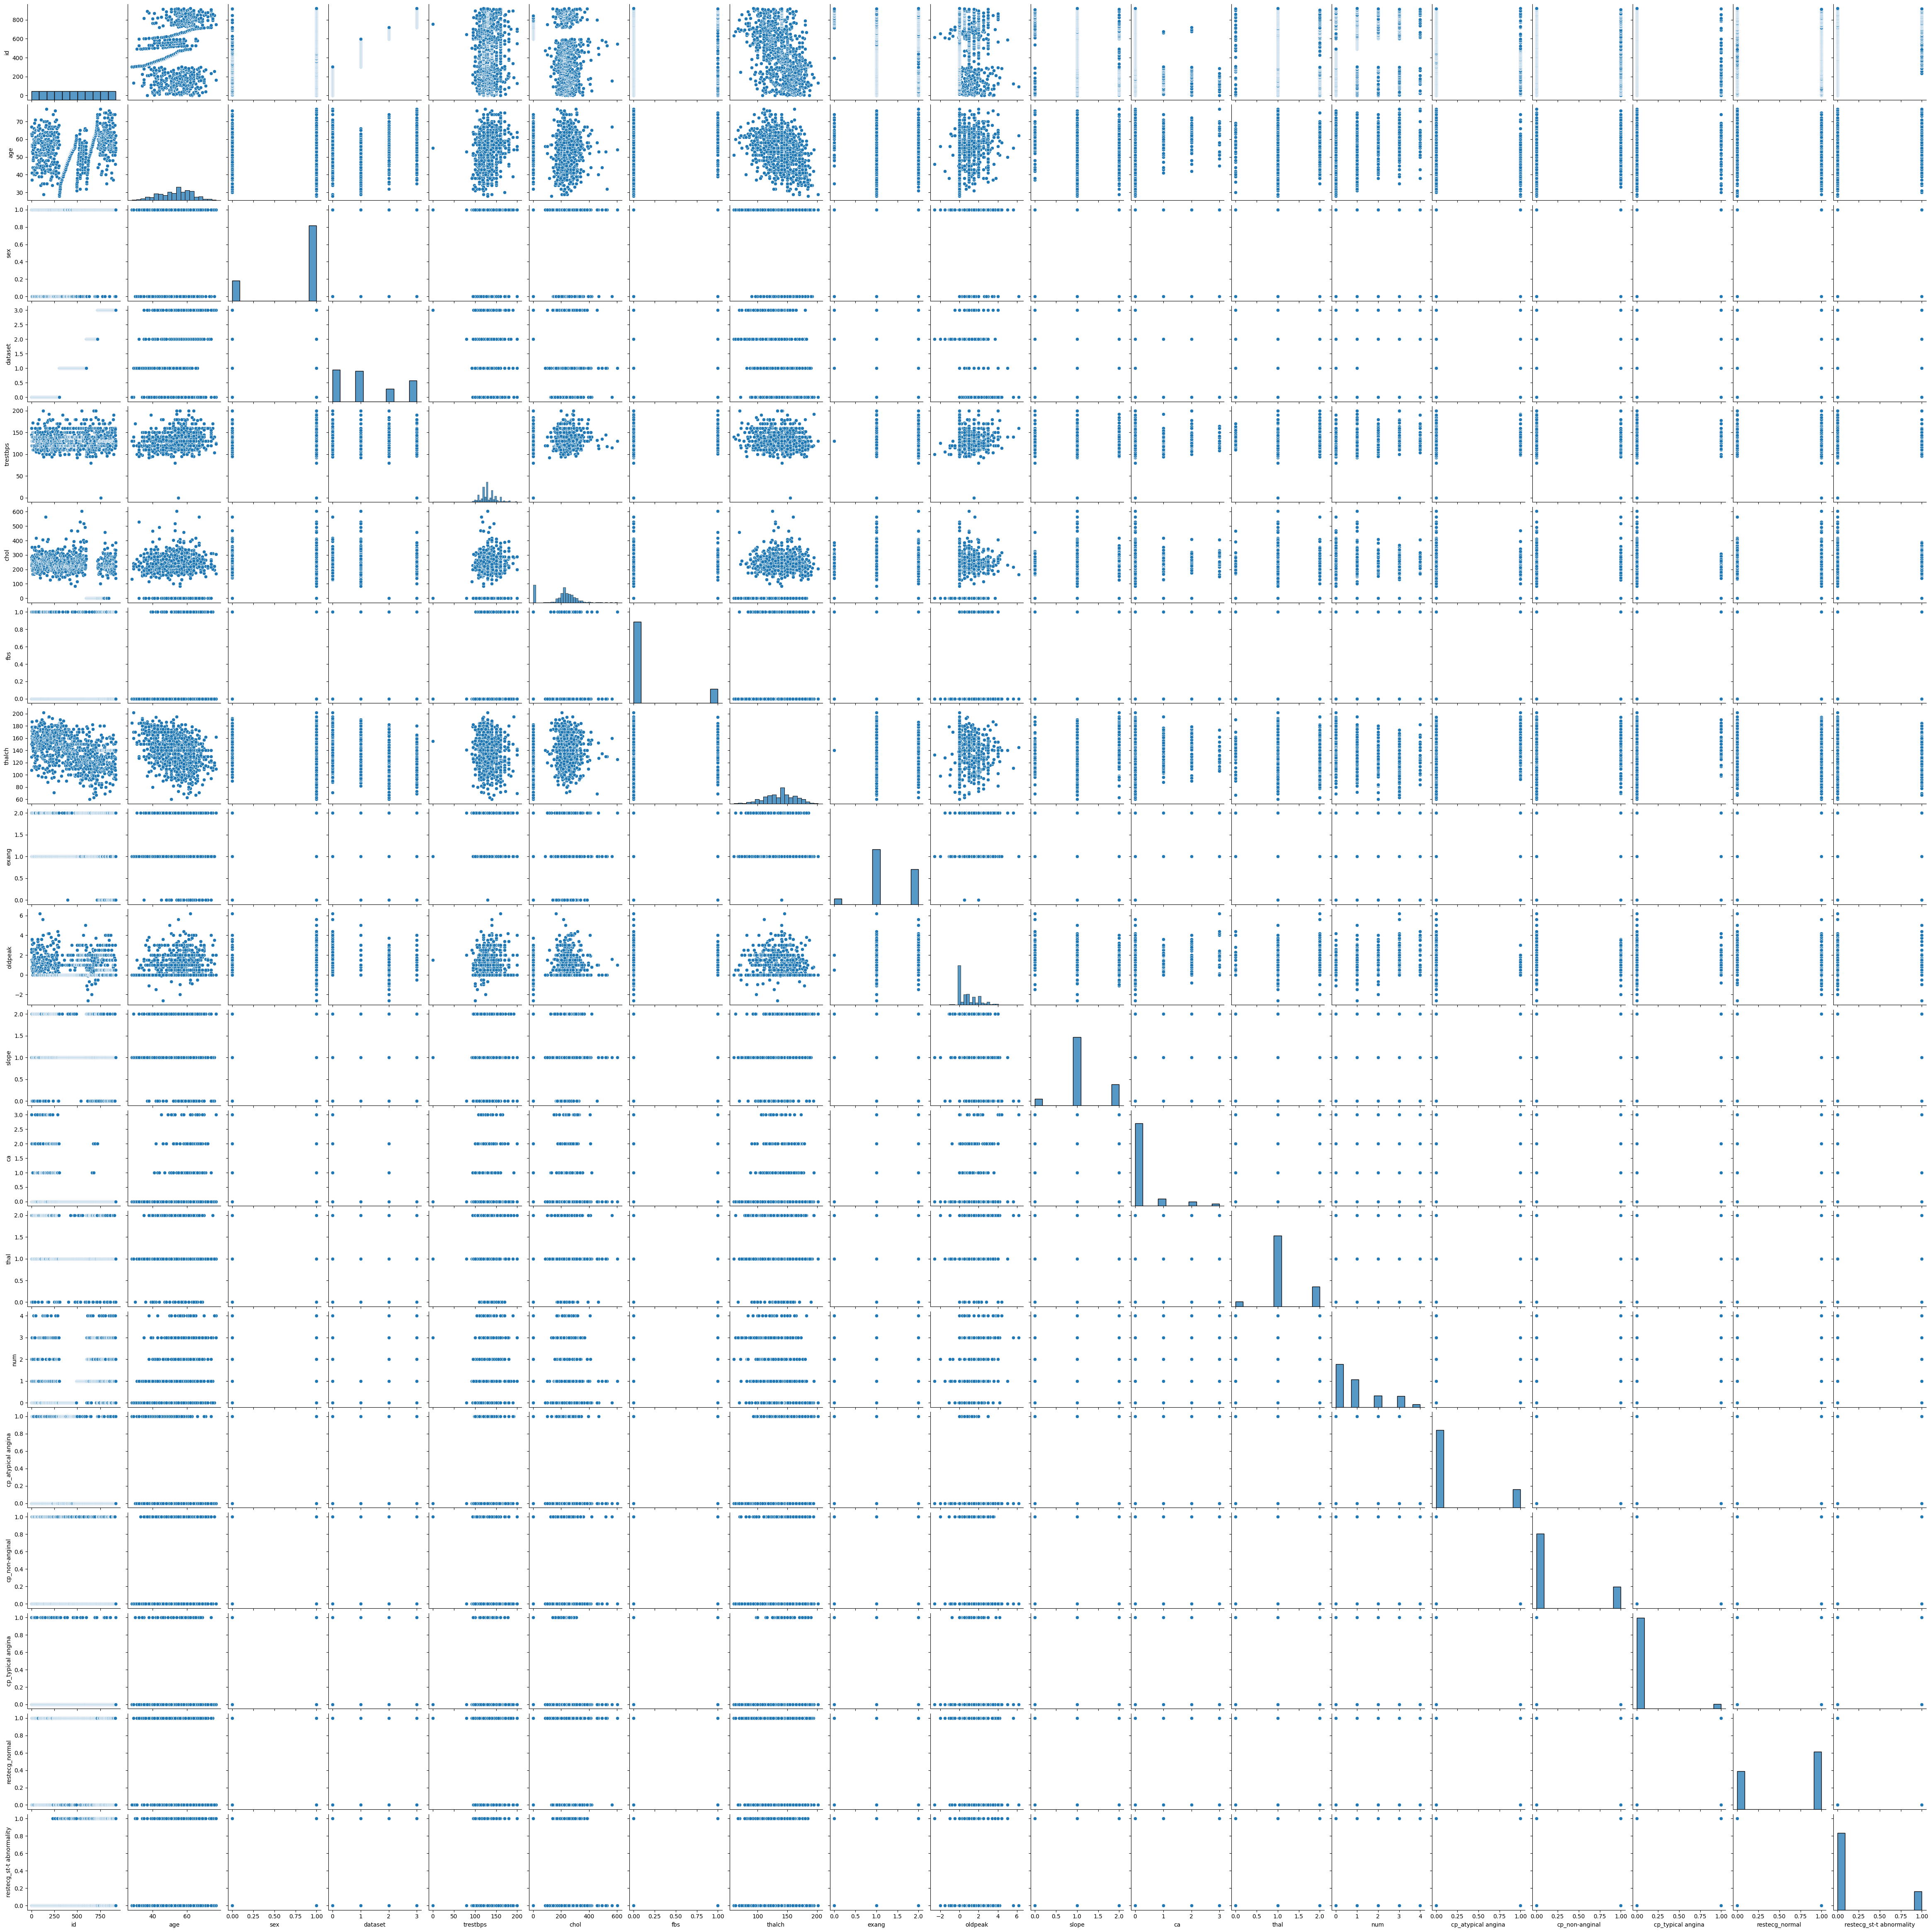

In [14]:
import seaborn as sns
sns.pairplot(df)

<Axes: >

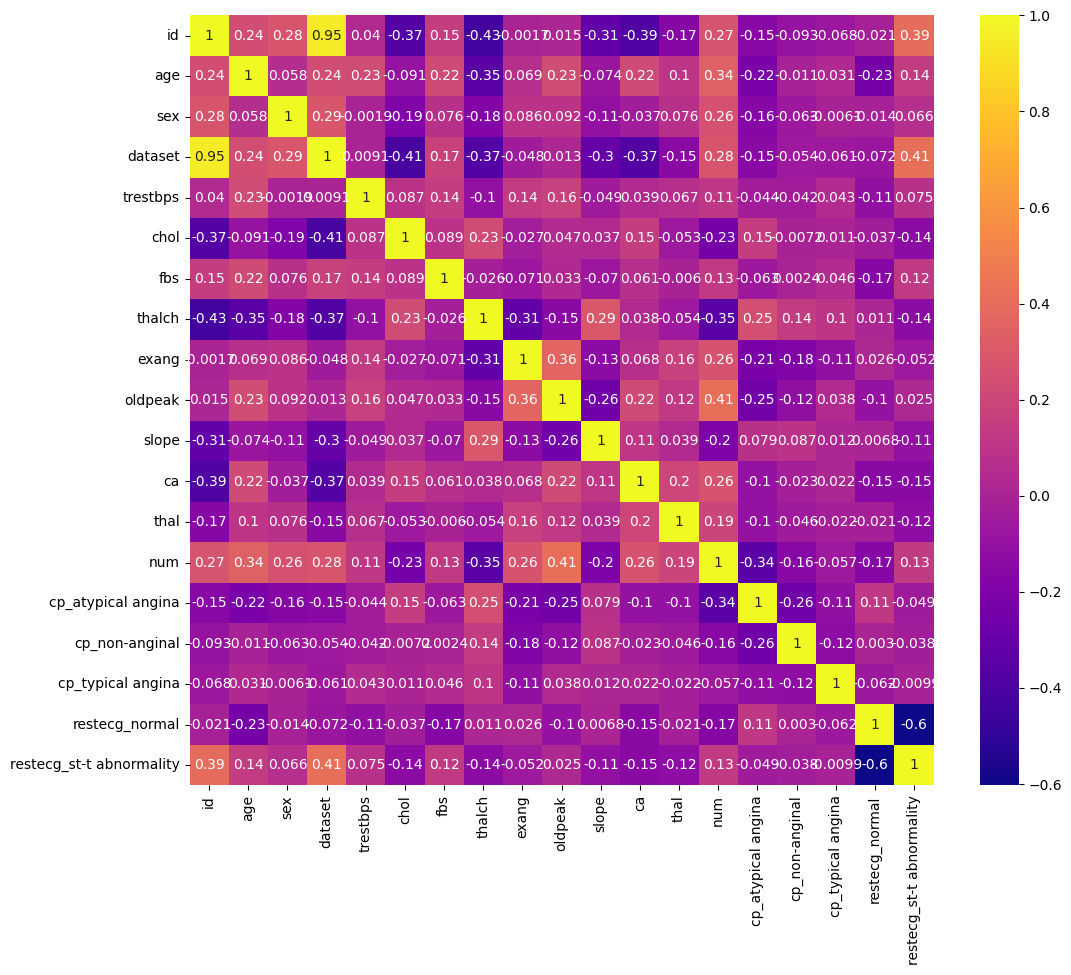

In [15]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap=plt.cm.plasma)

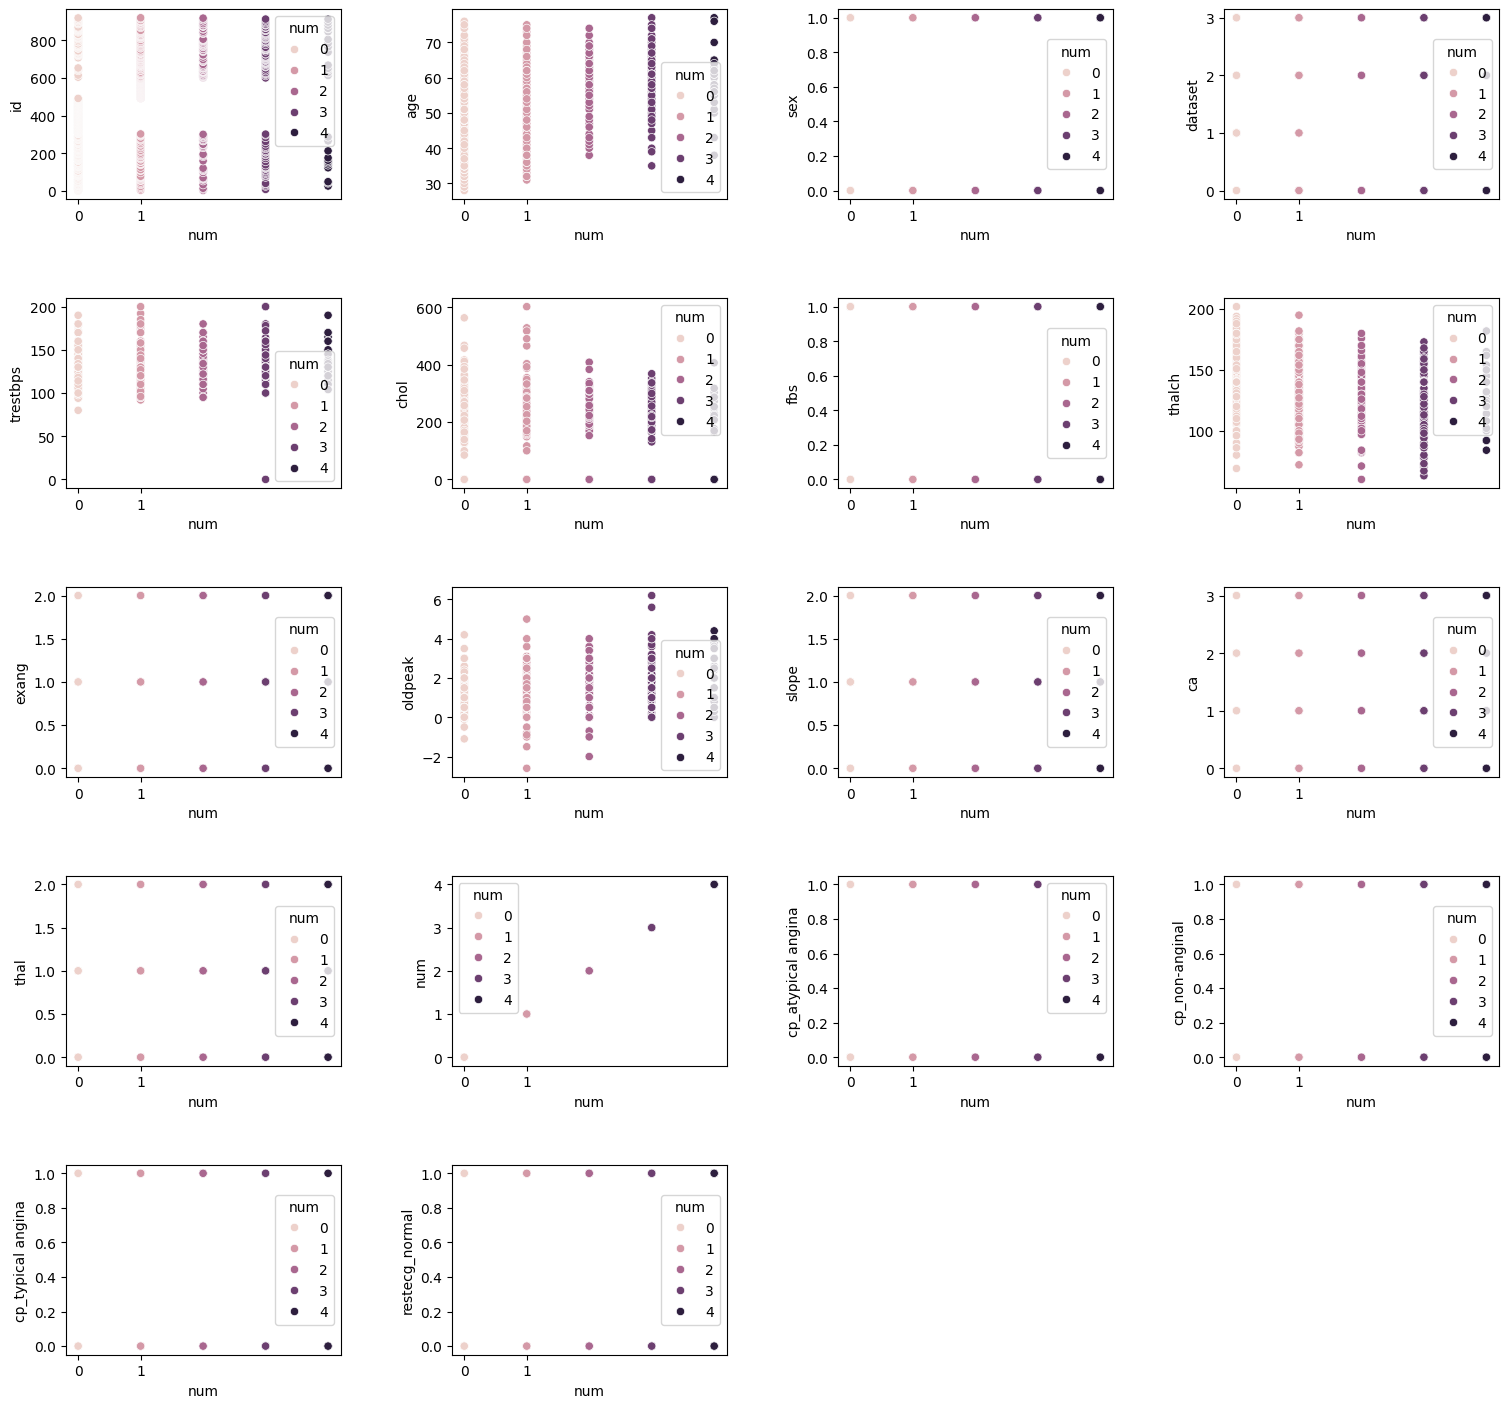

In [16]:
n_cols = 4
n_rows = -((-(len(df.columns) - 1)) // n_cols)

plt.figure(figsize=(n_cols * 4, n_rows * 3))
for i in range(len(df.columns) - 1):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.scatterplot(data=df, x='num', y=df.columns[i], hue='num')
    plt.xticks([0, 1])
plt.tight_layout(pad=4.0)

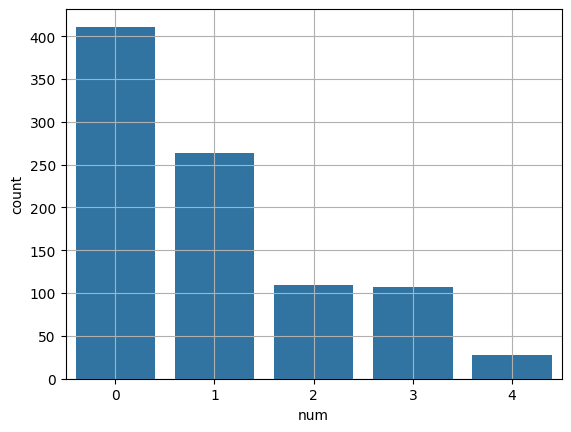

In [17]:
sns.countplot(x=df['num'])
plt.grid()


###Building and Training the Model

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('num', axis=1)
Y = df['num']

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.25, random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

def model(X_train, y_train):
    models = []

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    models.append(lr)

    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    models.append(tree)

    svm = SVC(kernel='rbf', gamma=0.1, C=1.0)
    svm.fit(X_train, y_train)
    models.append(svm)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    models.append(knn)

    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    models.append(rfc)

    nb = GaussianNB()
    nb.fit(X_train, y_train)
    models.append(nb)

    return models

In [20]:
from sklearn.metrics import accuracy_score, f1_score

# Call the function to train and get all models
models = model(X_train, y_train)
#Evaluating each model
for m in models:
    preds = m.predict(X_test)
    print(type(m).__name__)
    print(f"  Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"  F1 Score: {f1_score(y_test, preds, average='weighted'):.4f}")
    print()

LogisticRegression
  Accuracy: 0.5696
  F1 Score: 0.5463

DecisionTreeClassifier
  Accuracy: 0.5783
  F1 Score: 0.5680

SVC
  Accuracy: 0.5478
  F1 Score: 0.5126

KNeighborsClassifier
  Accuracy: 0.5478
  F1 Score: 0.5169

RandomForestClassifier
  Accuracy: 0.6130
  F1 Score: 0.5881

GaussianNB
  Accuracy: 0.2130
  F1 Score: 0.2547



In [21]:
accuracy_score

<function sklearn.metrics._classification.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)>